# Notebook 03 — Counterparty Exposure & XVA

**quant-desk-toolkit** · github.com/hyun-quant/quant-desk-toolkit

---

With simulated rate paths in hand, we can now answer: *what is the distribution of the swap's value at every future date?* That distribution defines counterparty credit risk.

This notebook covers:
1. **IRS revaluation** along each path using the Hull-White closed-form annuity
2. **Exposure profiles**: EE, EPE, PFE (95%), ENE
3. **XVA pricing**: CVA, DVA, FVA, MVA — the four standard valuation adjustments
4. **CVA sensitivities**: CS01 (credit spread), HR01 (hazard rate)

**Prerequisites**: `curves.pkl`, `mc_results.pkl`, `instruments.pkl`
**Outputs**: `exposure_results.pkl`, `xva_results.pkl`


## 0. Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from simulator import HullWhiteSimulator, MonteCarloEngine
from exposure import ExposureEngine, NettingSet
from xva import XVAEngine, build_hazard_rate_curve, survival_probability
from instruments import InterestRateSwap
from margin import MarginEngine, CSATerms

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

# Load prior notebooks' outputs
with open('curves.pkl', 'rb') as f:
    cd = pickle.load(f)
ois_curve  = cd['ois_curve']
sofr_curve = cd['sofr_curve']

with open('mc_results.pkl', 'rb') as f:
    mc = pickle.load(f)
mc_results = mc['mc_results']
time_grid  = mc['time_grid']
r_paths    = mc['r_paths']
path_dfs   = mc['path_dfs']
HW_A, HW_SIGMA = mc['hw_a'], mc['hw_sigma']

with open('instruments.pkl', 'rb') as f:
    inst = pickle.load(f)

hw_sim = HullWhiteSimulator(a=HW_A, sigma=HW_SIGMA, curve=ois_curve)
print(f'time_grid : {time_grid.shape},  r_paths : {r_paths.shape},  path_dfs : {path_dfs.shape}')

time_grid : (121,),  r_paths : (2000, 121),  path_dfs : (2000, 121)


---
## 1. IRS Revaluation Along Each Path

At each future time $t$ and path $\omega$, we re-value the IRS using the Hull-White closed-form bond price:

$$P(t, T_i | r(t)) = A(t,T_i) \cdot \exp(-B(t,T_i) \cdot r(t))$$

This gives us an exact closed-form MTM for every path-time combination, avoiding any nested simulation. The `ExposureEngine.irs_valuator()` returns a closure that does this vectorised across all paths.


In [12]:
# Reconstruct swap from instruments.pkl
swap = InterestRateSwap(
    notional          = inst['swap_notional'],
    fixed_rate        = inst['swap_fixed_rate'],
    tenor             = inst['swap_tenor'],
    payment_frequency = inst['swap_pay_freq'],
    float_frequency   = inst['swap_float_freq'],
    payer             = inst['swap_payer'],
)
payment_dates = swap._fixed_payment_dates()
print(f'Swap: {swap}')
print(f'Payment dates: {payment_dates}')

# Build exposure engine
exp_engine = ExposureEngine(mc_results, hw_sim)

# IRS valuator closure
irs_val = exp_engine.irs_valuator(
    fixed_rate    = swap.fixed_rate,
    payment_dates = payment_dates,
    notional      = swap.notional,
    payer         = swap.payer,
)

# Compute full MTM matrix: shape (n_paths, n_steps+1)
mtm_matrix = exp_engine.compute_mtm_matrix_vectorized(irs_val)
print(f'MTM matrix shape: {mtm_matrix.shape}')
print(f'MTM at t=0 (all paths identical): ${mtm_matrix[:,0].mean():,.2f}')
print(f'Expected: ${inst["swap_pv_net"]:,.2f}')

Swap: InterestRateSwap(Payer, N=10,000,000, K=4.5608%, T=5.0Y)
Payment dates: [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
MTM matrix shape: (2000, 121)
MTM at t=0 (all paths identical): $-99,340.44
Expected: $0.00


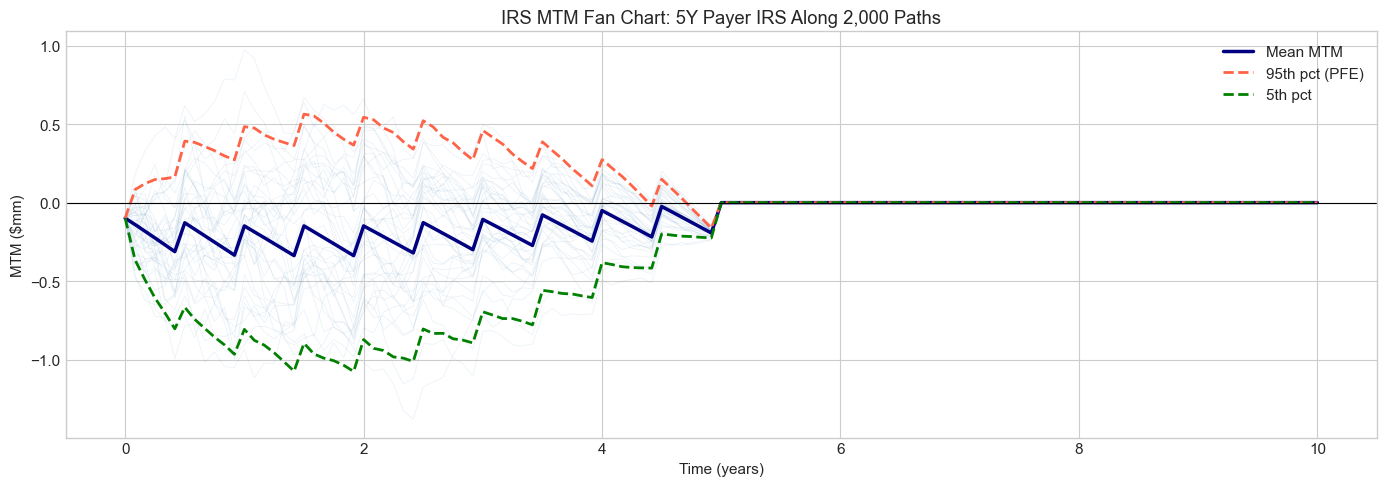

In [13]:
# Fan chart of IRS MTM paths
fig, ax = plt.subplots(figsize=(14, 5))
for i in range(0, 80, 2):
    ax.plot(time_grid, mtm_matrix[i]/1e6, alpha=0.10, lw=0.6, color='steelblue')
ax.plot(time_grid, mtm_matrix.mean(axis=0)/1e6, lw=2.5, color='navy', label='Mean MTM')
ax.plot(time_grid, np.percentile(mtm_matrix, 95, axis=0)/1e6, lw=2, color='tomato', ls='--', label='95th pct (PFE)')
ax.plot(time_grid, np.percentile(mtm_matrix, 5,  axis=0)/1e6, lw=2, color='green',  ls='--', label='5th pct')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_title('IRS MTM Fan Chart: 5Y Payer IRS Along 2,000 Paths')
ax.set_xlabel('Time (years)'); ax.set_ylabel('MTM ($mm)'); ax.legend()
plt.tight_layout(); plt.savefig('nb03_mtm_fan.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 2. Exposure Profiles

From the MTM matrix we compute standard counterparty risk metrics:

| Metric | Definition |
|---|---|
| **EE(t)** | $E[\max(V(t), 0)]$ — expected positive exposure at $t$ |
| **ENE(t)** | $E[\min(V(t), 0)]$ — expected negative exposure (our liability) |
| **PFE(t)** | 95th percentile of $\max(V(t),0)$ — worst-case exposure |
| **EPE** | $\frac{1}{T}\int_0^T EE(t)\,dt$ — time-averaged EE; Basel IMM input |

Note: these metrics are computed on **undiscounted** future PVs — each $V(t)$ is already the fair value at time $t$, not further discounted to $t=0$.


In [14]:
# Netting set: single payer IRS
ns = NettingSet(
    name            = 'IRS_payer_5Y',
    trade_valuators = [irs_val],
    threshold       = 0.0,
    minimum_transfer_amount = 0.0,
)

summary = exp_engine.exposure_summary(ns)
EE      = summary['EE']
ENE     = summary['ENE']
PFE_95  = summary['PFE_95']
EPE     = summary['EPE']

print(f'Exposure Summary:')
print(f'  EPE (time-averaged EE)  : ${EPE:>12,.0f}')
print(f'  Peak EE                 : ${EE.max():>12,.0f}')
print(f'  Peak PFE (95%)          : ${PFE_95.max():>12,.0f}')
print(f'  ENE at 1Y               : ${ENE[12]:>12,.0f}')

Exposure Summary:
  EPE (time-averaged EE)  : $      24,628
  Peak EE                 : $     106,073
  Peak PFE (95%)          : $     563,799
  ENE at 1Y               : $    -243,666


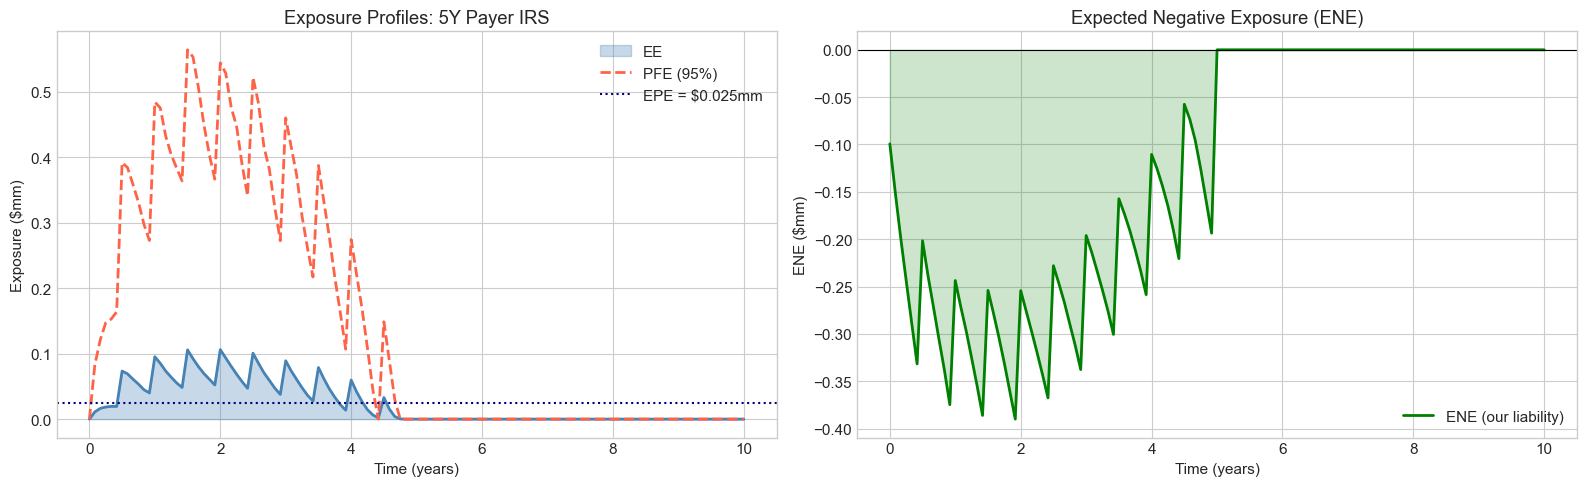

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.fill_between(time_grid, 0, EE/1e6, alpha=0.3, color='steelblue', label='EE')
ax.plot(time_grid, EE/1e6, lw=2, color='steelblue')
ax.plot(time_grid, PFE_95/1e6, lw=2, ls='--', color='tomato', label='PFE (95%)')
ax.axhline(y=EPE/1e6, lw=1.5, ls=':', color='navy', label=f'EPE = ${EPE/1e6:.3f}mm')
ax.set_title('Exposure Profiles: 5Y Payer IRS')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Exposure ($mm)'); ax.legend()

ax2 = axes[1]
ax2.plot(time_grid, ENE/1e6, lw=2, color='green', label='ENE (our liability)')
ax2.fill_between(time_grid, ENE/1e6, 0, alpha=0.2, color='green')
ax2.axhline(y=0, color='black', lw=0.8)
ax2.set_title('Expected Negative Exposure (ENE)')
ax2.set_xlabel('Time (years)'); ax2.set_ylabel('ENE ($mm)'); ax2.legend()

plt.tight_layout(); plt.savefig('nb03_exposure.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 3. Collateral Effect on Exposure

We add a second scenario with a VM-collateralised CSA to demonstrate how collateral dramatically reduces exposure. The `MarginEngine` simulates VM calls on the mean MTM path and provides an IM profile.


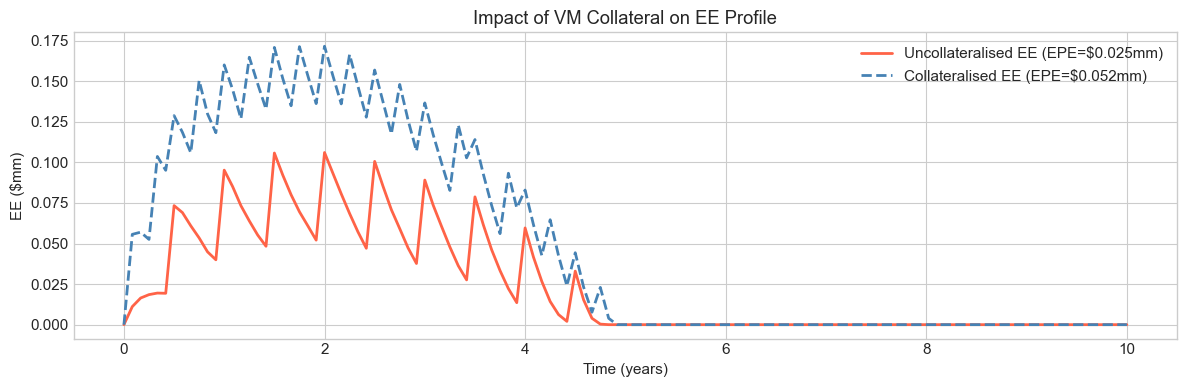

Collateral reduces EPE by -109.5%


In [16]:
# Uncollateralised EPE already computed above
epe_uncoll = EPE

# Collateralised: CSA with zero threshold
csa_zero = CSATerms(threshold_them=0.0, mta_them=100_000)
margin_engine = MarginEngine(csa=csa_zero, schedule_im_amount=0.0)
vm_result = margin_engine.vm_engine.simulate(mtm_matrix.mean(axis=0), time_grid)
vm_net    = vm_result['vm_net']

# Collateralised MTM = MTM - VM
mtm_coll = mtm_matrix - vm_net[np.newaxis, :]
EE_coll  = np.mean(np.maximum(mtm_coll, 0), axis=0)
horizon  = time_grid[-1]
epe_coll = np.sum(0.5*(EE_coll[:-1]+EE_coll[1:])*np.diff(time_grid)) / horizon

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_grid, EE/1e6, lw=2, color='tomato', label=f'Uncollateralised EE (EPE=${epe_uncoll/1e6:.3f}mm)')
ax.plot(time_grid, EE_coll/1e6, lw=2, ls='--', color='steelblue', label=f'Collateralised EE (EPE=${epe_coll/1e6:.3f}mm)')
ax.set_title('Impact of VM Collateral on EE Profile'); ax.legend()
ax.set_xlabel('Time (years)'); ax.set_ylabel('EE ($mm)')
plt.tight_layout(); plt.savefig('nb03_collateral.png', dpi=120, bbox_inches='tight'); plt.show()
print(f'Collateral reduces EPE by {(1-epe_coll/epe_uncoll)*100:.1f}%')

---
## 4. XVA Pricing

The three primary valuation adjustments:

**CVA** (Credit Valuation Adjustment — counterparty default risk):
$$CVA = LGD_c \int_0^T EE(t) \cdot \lambda_c(t) \cdot P_{surv,c}(t)\, dt$$

**DVA** (Debt Valuation Adjustment — our own default):
$$DVA = LGD_b \int_0^T ENE(t) \cdot \lambda_b(t) \cdot P_{surv,b}(t)\, dt$$

**FVA** (Funding Valuation Adjustment):
$$FCA = s_f \int_0^T EE(t)\, dt, \quad FVA = FCA + FBA$$

**MVA** (Margin Valuation Adjustment — cost of posting IM):
$$MVA = s_f \int_0^T IM(t) \cdot P_{surv,b}(t)\, dt$$


In [17]:
# Counterparty credit curve: BBB, 120bp CDS spread → hazard rate ≈ 120/(1-0.40) = 200bp
cpty_tenors       = np.array([0.0, 1.0, 3.0, 5.0, 7.0, 10.0])
cpty_hazard_rates = np.array([0.020, 0.020, 0.020, 0.020, 0.020, 0.020])  # flat 2% hazard

# Our own credit curve: A-, 80bp CDS → ~133bp hazard
own_tenors       = np.array([0.0, 1.0, 3.0, 5.0, 7.0, 10.0])
own_hazard_rates = np.array([0.0133, 0.0133, 0.0133, 0.0133, 0.0133, 0.0133])

# IM profile for MVA: use MarginEngine linear decay from schedule IM
schedule_im = 500_000   # $500K initial margin (SIMM approximation)
margin_eng  = MarginEngine(csa=CSATerms(), schedule_im_amount=schedule_im)
im_profile  = margin_eng.im_profile(time_grid, decay='linear', portfolio_maturity=5.0)

xva_engine = XVAEngine(
    ee_profile                = EE,
    ene_profile               = ENE,
    time_grid                 = time_grid,
    counterparty_tenors       = cpty_tenors,
    counterparty_hazard_rates = cpty_hazard_rates,
    counterparty_recovery     = 0.40,
    own_tenors                = own_tenors,
    own_hazard_rates          = own_hazard_rates,
    own_recovery              = 0.40,
    funding_spread            = 0.0050,   # 50bp funding spread
    use_symmetric_fva         = True,
    im_profile                = im_profile,
)

xva = xva_engine.compute()

print('XVA Summary:')
print(f'  CVA          : ${xva["CVA"]:>10,.0f}  (credit cost)')
print(f'  DVA          : ${xva["DVA"]:>10,.0f}  (our credit benefit)')
print(f'  BCVA         : ${xva["BCVA"]:>10,.0f}  (bilateral)')
print(f'  FCA          : ${xva["FCA"]:>10,.0f}')
print(f'  FBA          : ${xva["FBA"]:>10,.0f}')
print(f'  FVA          : ${xva["FVA"]:>10,.0f}')
print(f'  MVA          : ${xva["MVA"]:>10,.0f}')
print(f'  Total XVA    : ${xva["total_XVA"]:>10,.0f}')
print(f'  CS01         : ${xva["CS01"]:>10,.2f}  (CVA per 1bp CDS spread)')
print(f'  HR01         : ${xva["HR01"]:>10,.2f}  (CVA per 1bp hazard rate)')

XVA Summary:
  CVA          : $     2,746  (credit cost)
  DVA          : $    -9,671  (our credit benefit)
  BCVA         : $    -6,925  (bilateral)
  FCA          : $     1,194
  FBA          : $    -6,242
  FVA          : $    -5,047
  MVA          : $     6,114
  Total XVA    : $    -5,859
  CS01         : $     21.90  (CVA per 1bp CDS spread)
  HR01         : $     13.14  (CVA per 1bp hazard rate)


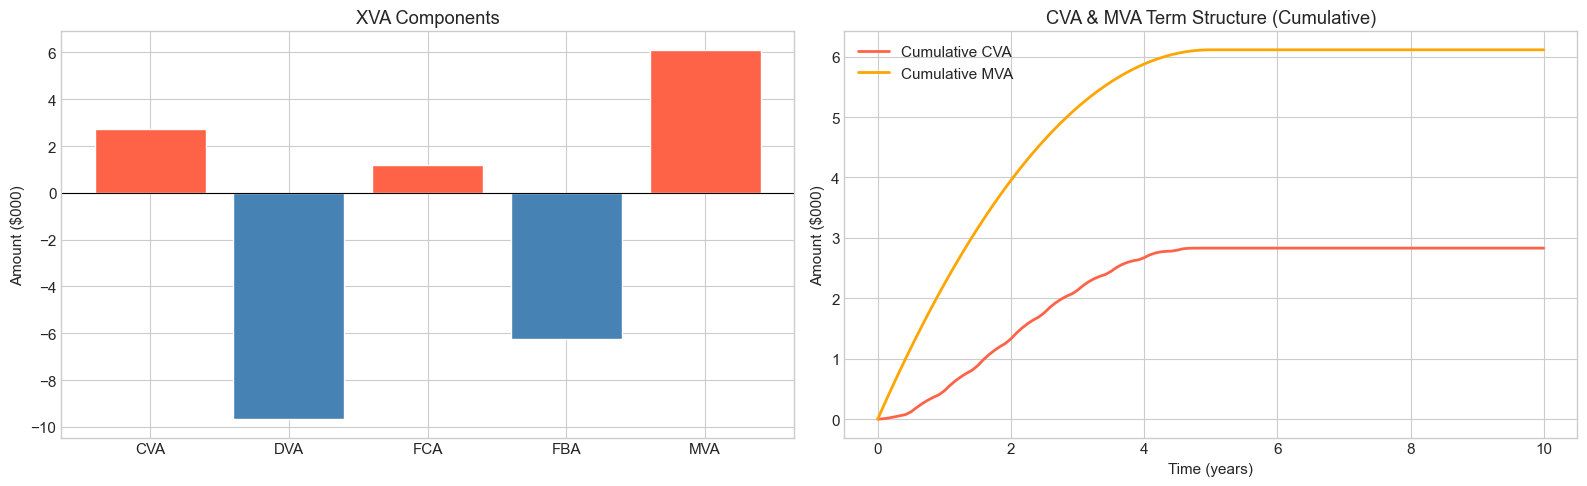

In [18]:
# XVA waterfall chart
labels  = ['CVA', 'DVA', 'FCA', 'FBA', 'MVA']
values  = [xva['CVA'], xva['DVA'], xva['FCA'], xva['FBA'], xva['MVA']]
colors  = ['tomato' if v > 0 else 'steelblue' for v in values]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(labels, [v/1e3 for v in values], color=colors, edgecolor='white')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_title('XVA Components'); ax.set_ylabel('Amount ($000)')

ax2 = axes[1]
ax2.plot(time_grid, xva['CVA_term_structure']/1e3, lw=2, color='tomato', label='Cumulative CVA')
ax2.plot(time_grid, xva['MVA_term_structure']/1e3, lw=2, color='orange', label='Cumulative MVA')
ax2.set_title('CVA & MVA Term Structure (Cumulative)')
ax2.set_xlabel('Time (years)'); ax2.set_ylabel('Amount ($000)'); ax2.legend()

plt.tight_layout(); plt.savefig('nb03_xva.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 5. CVA Sensitivities

**CS01**: CVA change per 1bp parallel shift in the counterparty CDS par spread curve
**HR01**: CVA change per 1bp parallel shift in the hazard rate curve

Relationship: $CS01 = HR01 \times LGD$ (credit triangle approximation, $\Delta\lambda = \Delta s / LGD$)


In [19]:
print('CVA Sensitivity Analysis:')
print(f'  CVA base          : ${xva["CVA"]:>10,.2f}')
print(f'  CS01 (1bp spread) : ${xva["CS01"]:>10,.2f}')
print(f'  HR01 (1bp hazard) : ${xva["HR01"]:>10,.2f}')
print(f'  CS01/HR01 ratio   : {xva["CS01"]/xva["HR01"]:.4f}  (expected: 1-R = 0.60)')
print()

# Bucketed CS01: shift each 1Y pillar by 1bp
print('Bucketed CS01 by pillar:')
print(f'{"Pillar":>8}  {"CS01 ($)":>12}')
print('-' * 24)
from xva import CVAEngine, build_hazard_rate_curve, survival_probability

for i, tenor in enumerate(cpty_tenors[1:], 1):  # skip t=0
    hr_bump = cpty_hazard_rates.copy()
    hr_bump[i] += 1e-4 / 0.60   # 1bp CDS → 1/LGD bp hazard
    from xva import CVAEngine as CE
    cva_bump = CE(EE, time_grid, cpty_tenors, hr_bump, recovery_rate=0.40).compute()
    cva_base = CE(EE, time_grid, cpty_tenors, cpty_hazard_rates, recovery_rate=0.40).compute()
    print(f'{tenor:>7.0f}Y  ${cva_bump - cva_base:>10,.2f}')

CVA Sensitivity Analysis:
  CVA base          : $  2,746.14
  CS01 (1bp spread) : $     21.90
  HR01 (1bp hazard) : $     13.14
  CS01/HR01 ratio   : 1.6664  (expected: 1-R = 0.60)

Bucketed CS01 by pillar:
  Pillar      CS01 ($)
------------------------
      1Y  $      8.96
      3Y  $     10.11
      5Y  $      1.66
      7Y  $      0.00
     10Y  $      0.00


---
## 6. Save Outputs

In [20]:
exposure_results = {
    'EE'          : EE,
    'ENE'         : ENE,
    'PFE_95'      : PFE_95,
    'EPE'         : EPE,
    'EE_coll'     : EE_coll,
    'epe_coll'    : epe_coll,
    'mtm_matrix'  : mtm_matrix,
    'im_profile'  : im_profile,
    'time_grid'   : time_grid,
}
with open('exposure_results.pkl', 'wb') as f:
    pickle.dump(exposure_results, f)
print('Saved exposure_results.pkl')

xva_results = {
    'xva'                : xva,
    'cpty_tenors'        : cpty_tenors,
    'cpty_hazard_rates'  : cpty_hazard_rates,
    'own_tenors'         : own_tenors,
    'own_hazard_rates'   : own_hazard_rates,
    'funding_spread'     : 0.0050,
    'schedule_im'        : schedule_im,
}
with open('xva_results.pkl', 'wb') as f:
    pickle.dump(xva_results, f)
print('Saved xva_results.pkl')
print()
print('Proceed to: notebook_04_sa_ccr_capital.ipynb')

Saved exposure_results.pkl
Saved xva_results.pkl

Proceed to: notebook_04_sa_ccr_capital.ipynb
